# Лабораторная работа №2

In [165]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression, HuberRegressor, RANSACRegressor, TheilSenRegressor, SGDRegressor, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error,r2_score,  mean_absolute_percentage_error
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
from scipy.stats import uniform, loguniform
from metrics import mse, rmse, mae, r_2, mape
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
# sns.set_palette("husl")

In [114]:
data = pd.read_csv("data_sets/air_without_min_max.csv")
data.drop("Unnamed: 0", axis=1, inplace=True)
data

,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,year,month,day,day_of_week,hour
0,2.600,1360,11.900,1046,166,113,1692,1268,13.600,48.900,0.758,2004,3,10,3,18
1,2.000,1292,9.400,955,103,92,1559,972,13.300,47.700,0.726,2004,3,10,3,19
2,2.200,1402,9.000,939,131,114,1555,1074,11.900,54.000,0.750,2004,3,10,3,20
3,2.200,1376,9.200,948,172,122,1584,1203,11.000,60.000,0.787,2004,3,10,3,21
4,1.600,1272,6.500,836,131,116,1490,1110,11.200,59.600,0.789,2004,3,10,3,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8870,3.100,1314,13.500,1101,472,190,1374,1729,21.900,29.300,0.757,2005,4,4,1,10
8871,2.400,1163,11.400,1027,353,179,1264,1269,24.300,23.700,0.712,2005,4,4,1,11
8872,2.400,1142,12.400,1063,293,175,1241,1092,26.900,18.300,0.641,2005,4,4,1,12
8873,2.100,1003,9.500,961,235,156,1041,770,28.300,13.500,0.514,2005,4,4,1,13


Для всех моделей в качестве таргета будем использовать `CO(GT)` - количество угарного газа в воздухе.

In [115]:
y = data["CO(GT)"]

In [116]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Train Data", "Test Data"],
    metrics
])

train_and_test_comparing = pd.DataFrame(columns=columns)
train_and_test_comparing

Empty DataFrame
Columns: [(Train Data, R2), (Train Data, MSE), (Train Data, RMSE), (Train Data, MAE), (Train Data, MAPE), (Test Data, R2), (Test Data, MSE), (Test Data, RMSE), (Test Data, MAE), (Test Data, MAPE)]
Index: []

In [117]:
metrics = ["R2", "MSE", "RMSE", "MAE", "MAPE"]

columns = pd.MultiIndex.from_product([
    ["Scikit-learn", "Кастомные функции"],
    metrics
])

sklearn_and_custom_comparing = pd.DataFrame(columns=columns)
pd.options.display.float_format = '{:.3f}'.format
sklearn_and_custom_comparing

Empty DataFrame
Columns: [(Scikit-learn, R2), (Scikit-learn, MSE), (Scikit-learn, RMSE), (Scikit-learn, MAE), (Scikit-learn, MAPE), (Кастомные функции, R2), (Кастомные функции, MSE), (Кастомные функции, RMSE), (Кастомные функции, MAE), (Кастомные функции, MAPE)]
Index: []

In [118]:
def get_metrics_value(y_predict, y_test):
    sklearn_metrics = [r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_error,
                       mean_absolute_percentage_error]
    custom_metrics = [r_2, mse, rmse, mae, mape]
    sklearn_metrics_results = []
    custom_metrics_results = []

    for sklearn_metric, custom_metric in zip(sklearn_metrics, custom_metrics):
        sklearn_metrics_results.append(sklearn_metric(y_test, y_predict))
        custom_metrics_results.append(custom_metric(y_test, y_predict))

    return sklearn_metrics_results, custom_metrics_results


In [119]:
def input_into_the_tables(name_of_model,
                          predict_on_train_y, y_train,
                          predict_on_test_y, y_test,
                          sklearn_and_custom_comparing,
                          train_and_test_comparing):
    sk_learn_test_metrics, custom_test_metrics = get_metrics_value(predict_on_test_y, y_test)
    sklearn_and_custom_comparing.loc[name_of_model] = sk_learn_test_metrics + custom_test_metrics

    sk_learn_train_metrics, _ = get_metrics_value(predict_on_train_y, y_train)
    train_and_test_comparing.loc[name_of_model] = sk_learn_train_metrics + sk_learn_test_metrics


### Простая линейная регрессия

Для построения модели простой линейной регрессии в качестве предикта будем использовать признак `PT08.S1(CO)` - показатели датчика S1 об уровне CO в воздухе.

In [120]:
X = data.drop("CO(GT)", axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_simple_train = X_train[["C6H6(GT)"]]
X_simple_test = X_test[["C6H6(GT)"]]

In [121]:
model = LinearRegression()
model.fit(X_simple_train, y_train)
simple_regression_predict_on_test_y = model.predict(X_simple_test)
simple_regression_predict_on_train_y = model.predict(X_simple_train)
model.coef_

array([0.15091156])

Text(0.5, 1.0, 'Простая регрессия')

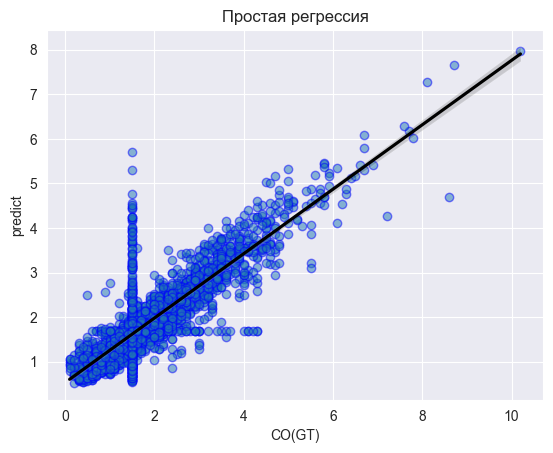

In [122]:
sns.regplot(y = simple_regression_predict_on_test_y, x = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.ylabel("predict")
plt.title("Простая регрессия")

In [123]:
input_into_the_tables("Linear regression",
                      simple_regression_predict_on_train_y, y_train,
                      simple_regression_predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [124]:
sklearn_and_custom_comparing.loc["Linear regression"]

Scikit-learn       R2     0.729
                   MSE    0.400
                   RMSE   0.632
                   MAE    0.430
                   MAPE   0.330
Кастомные функции  R2     0.729
                   MSE    0.400
                   RMSE   0.632
                   MAE    0.430
                   MAPE   0.330
Name: Linear regression, dtype: float64

In [125]:
train_and_test_comparing.loc["Linear regression"]

Train Data  R2     0.697
            MSE    0.440
            RMSE   0.664
            MAE    0.450
            MAPE   0.353
Test Data   R2     0.729
            MSE    0.400
            RMSE   0.632
            MAE    0.430
            MAPE   0.330
Name: Linear regression, dtype: float64

#### Простая линейная регрессия с регуляризатором L1

Регуляризация с помощью Optuna

In [126]:
def lasso_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-10, 1e10, log=True)
    model = Lasso(alpha=alpha)
    model.fit(X_simple_train, y_train)
    y_pred = model.predict(X_simple_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [127]:
study = optuna.create_study(direction="minimize")
study.optimize(lasso_objective, n_trials=100)
best_params = study.best_params
best_params

[I 2026-03-05 05:01:10,812] A new study created in memory with name: no-name-4f3d1e13-73ba-490e-af42-fc968d65437a
[I 2026-03-05 05:01:10,828] Trial 0 finished with value: 0.39969370811034655 and parameters: {'alpha': 0.007887177272406738}. Best is trial 0 with value: 0.39969370811034655.
[I 2026-03-05 05:01:10,828] Trial 1 finished with value: 0.3996718720063595 and parameters: {'alpha': 0.00024724539089001523}. Best is trial 1 with value: 0.3996718720063595.
[I 2026-03-05 05:01:10,828] Trial 2 finished with value: 1.4743191658796424 and parameters: {'alpha': 1002.4662790633025}. Best is trial 1 with value: 0.3996718720063595.
[I 2026-03-05 05:01:10,844] Trial 3 finished with value: 1.4743191658796424 and parameters: {'alpha': 519748.3077981273}. Best is trial 1 with value: 0.3996718720063595.
[I 2026-03-05 05:01:10,844] Trial 4 finished with value: 0.3997647383988926 and parameters: {'alpha': 0.028110853866403576}. Best is trial 1 with value: 0.3996718720063595.
[I 2026-03-05 05:01:10

{'alpha': 1.001438377934198e-10}

In [128]:
lasso_model = Lasso(alpha=best_params["alpha"])
lasso_model.fit(X_simple_train, y_train)
lasso_model.coef_

array([0.15091156])

С применением Lasso регуляризации значение веса не изменилось.

In [129]:
l1_regression_predict_on_train_y = lasso_model.predict(X_simple_train)
l1_regression_predict_on_test_y = lasso_model.predict(X_simple_test)

In [130]:
input_into_the_tables("Linear regression with L1",
                      l1_regression_predict_on_train_y, y_train,
                      l1_regression_predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

Text(0.5, 1.0, 'Простая регрессия с L1 регуляризацией')

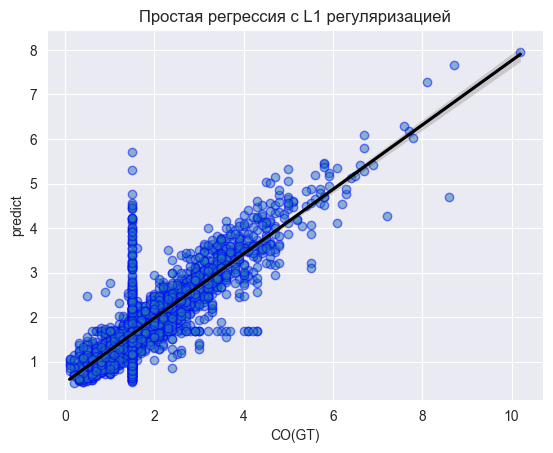

In [131]:
sns.regplot(y=l1_regression_predict_on_test_y, x = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})
plt.ylabel("predict")
plt.title("Простая регрессия с L1 регуляризацией")

Text(0.5, 1.0, 'Простая регрессия с L1 регуляризацией')

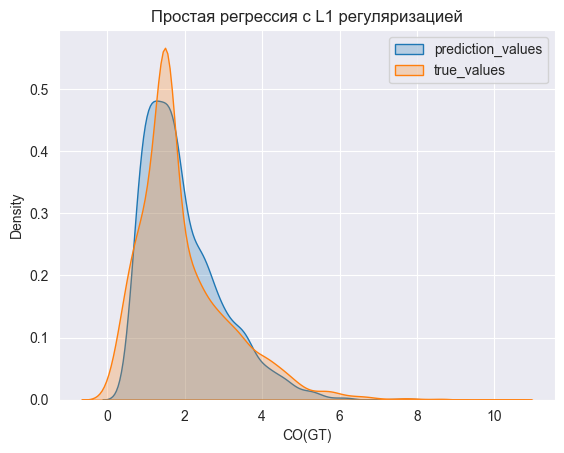

In [132]:
sns.kdeplot(l1_regression_predict_on_test_y, label="prediction_values", fill=True)
sns.kdeplot(y_test, label="true_values", fill=True)
plt.legend()
plt.title("Простая регрессия с L1 регуляризацией")

#### Простая линейная регрессия с регуляризатором L2

In [133]:
ridge_model = Ridge()
param_grid = {'alpha':np.logspace(-10, 10)}

randomize_search = RandomizedSearchCV(
    estimator = ridge_model,
    param_distributions = param_grid,
    scoring="neg_mean_squared_error"
)

randomize_search.fit(X_simple_train, y_train)
print(randomize_search.best_params_)

{'alpha': np.float64(7.196856730011529e-08)}


In [134]:
randomize_search.best_estimator_.coef_

array([0.15091156])

После применения Ridge регуляризации значение веса не изменилось.

In [135]:
l2_regression_predict_on_train_y = randomize_search.predict(X_simple_train)
l2_regression_predict_on_test_y = randomize_search.predict(X_simple_test)

In [136]:
input_into_the_tables("Linear regression with L2",
                      l2_regression_predict_on_train_y, y_train,
                      l2_regression_predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

Text(0.5, 1.0, 'Простая регрессия с L2 регуляризацией')

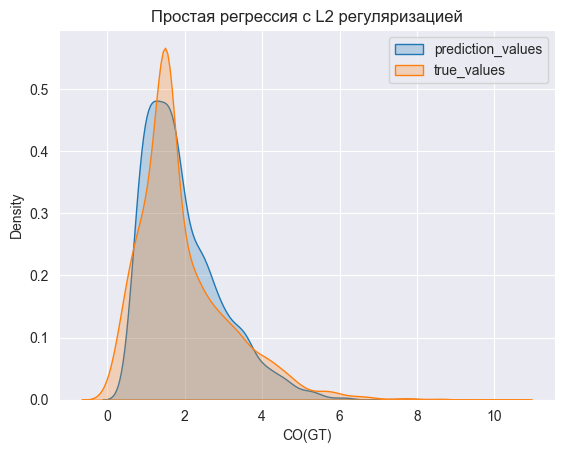

In [137]:
sns.kdeplot(l2_regression_predict_on_test_y, label="prediction_values", fill=True)
sns.kdeplot(y_test, label="true_values", fill=True)
plt.legend()
plt.title("Простая регрессия с L2 регуляризацией")

#### Простая линейная регрессия с ElasticNet

In [138]:
base_elastic_model = ElasticNet(max_iter=100000)
param_grid = {'alpha':np.logspace(-10, 10)}
grid_search = GridSearchCV(
    estimator=base_elastic_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
)
grid_search.fit(X_simple_train, y_train)
print(grid_search.best_params_)

{'alpha': np.float64(1e-10)}


In [139]:
elasticnet_regression_predict_on_train_y = grid_search.predict(X_simple_train)
elasticnet_regression_predict_on_test_y = grid_search.predict(X_simple_test)
input_into_the_tables("Linear regression with ElasticNet",
                      elasticnet_regression_predict_on_train_y, y_train,
                      elasticnet_regression_predict_on_test_y, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

Text(0.5, 1.0, 'Простая регрессия с ElasticNet регуляризацией')

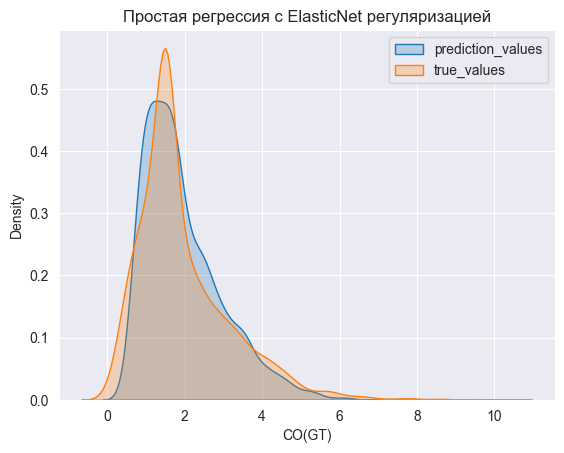

In [140]:
sns.kdeplot(elasticnet_regression_predict_on_test_y, label="prediction_values", fill=True)
sns.kdeplot(y_test, label="true_values", fill=True)
plt.legend()
plt.title("Простая регрессия с ElasticNet регуляризацией")

In [141]:
sklearn_and_custom_comparing

Scikit-learn                          \
                                            R2   MSE  RMSE   MAE  MAPE   
Linear regression                        0.729 0.400 0.632 0.430 0.330   
Linear regression with L1                0.729 0.400 0.632 0.430 0.330   
Linear regression with L2                0.729 0.400 0.632 0.430 0.330   
Linear regression with ElasticNet        0.729 0.400 0.632 0.430 0.330   

                                  Кастомные функции                          
                                                 R2   MSE  RMSE   MAE  MAPE  
Linear regression                             0.729 0.400 0.632 0.430 0.330  
Linear regression with L1                     0.729 0.400 0.632 0.430 0.330  
Linear regression with L2                     0.729 0.400 0.632 0.430 0.330  
Linear regression with ElasticNet             0.729 0.400 0.632 0.430 0.330

In [142]:
train_and_test_comparing

Train Data                          \
                                          R2   MSE  RMSE   MAE  MAPE   
Linear regression                      0.697 0.440 0.664 0.450 0.353   
Linear regression with L1              0.697 0.440 0.664 0.450 0.353   
Linear regression with L2              0.697 0.440 0.664 0.450 0.353   
Linear regression with ElasticNet      0.697 0.440 0.664 0.450 0.353   

                                  Test Data                          
                                         R2   MSE  RMSE   MAE  MAPE  
Linear regression                     0.729 0.400 0.632 0.430 0.330  
Linear regression with L1             0.729 0.400 0.632 0.430 0.330  
Linear regression with L2             0.729 0.400 0.632 0.430 0.330  
Linear regression with ElasticNet     0.729 0.400 0.632 0.430 0.330

### Множественная линейная регрессия

In [143]:
model = LinearRegression()
model.fit(X_train, y_train)
multiple_reg_train_prediction = model.predict(X_train)
multiple_reg_test_prediction = model.predict(X_test)

input_into_the_tables("Multiple regression",
                      multiple_reg_train_prediction, y_train,
                      multiple_reg_test_prediction, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

model.coef_

array([ 1.03135553e-03,  1.39904678e-01, -3.24357030e-03,  3.08818877e-03,
        4.55664152e-03,  1.31076947e-03, -1.82487702e-04, -1.47100764e-02,
       -4.22197927e-03, -2.65909024e-01, -2.25366490e-01,  5.10426932e-03,
        1.24397427e-03,  8.65644253e-03,  9.63407724e-03])

Веса некоторых признаков крайне малы.

<Axes: xlabel='CO(GT)'>

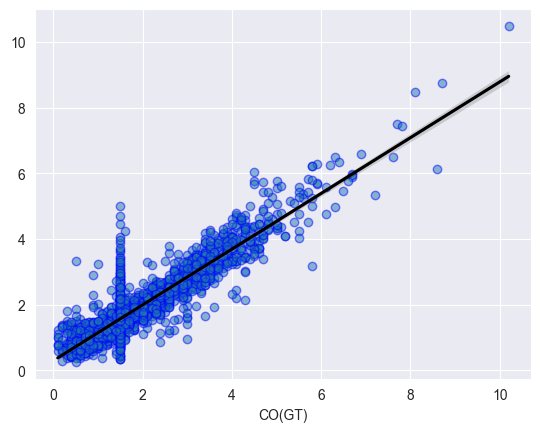

In [144]:
sns.regplot(y = multiple_reg_test_prediction, x = y_test,
            scatter_kws={"edgecolor": "blue", "alpha": 0.5},
            line_kws={"color": "black"})

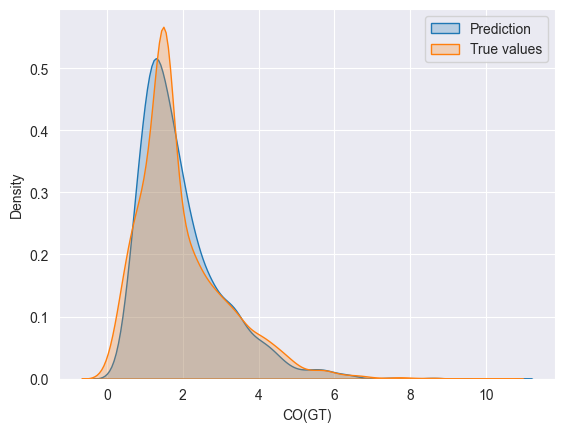

In [145]:
sns.kdeplot(x = multiple_reg_test_prediction, fill=True, label="Prediction")
sns.kdeplot(x = y_test, fill=True, label="True values")
plt.legend()

In [146]:
train_and_test_comparing.loc[["Linear regression", "Multiple regression"]]

Train Data                         Test Data              \
                            R2   MSE  RMSE   MAE  MAPE        R2   MSE  RMSE   
Linear regression        0.697 0.440 0.664 0.450 0.353     0.729 0.400 0.632   
Multiple regression      0.831 0.245 0.495 0.339 0.298     0.838 0.239 0.489   

                                 
                      MAE  MAPE  
Linear regression   0.430 0.330  
Multiple regression 0.328 0.280

### Множественная линейная регрессия c L1 регуляризацией

In [147]:
def lasso_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-10, 1e10, log=True)
    model = Lasso(alpha=alpha)
    model.fit(X_simple_train, y_train)
    y_pred = model.predict(X_simple_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

In [148]:
study = optuna.create_study(direction="minimize")
study.optimize(lasso_objective, n_trials=100)
best_params = study.best_params
best_params

[I 2026-03-05 05:01:16,908] A new study created in memory with name: no-name-d839db50-acc9-433c-8c8d-c85f1fc3b57c
[I 2026-03-05 05:01:16,919] Trial 0 finished with value: 0.3997031252363409 and parameters: {'alpha': 0.01091654687452637}. Best is trial 0 with value: 0.3997031252363409.
[I 2026-03-05 05:01:16,925] Trial 1 finished with value: 1.4743191658796424 and parameters: {'alpha': 793434956.6791636}. Best is trial 0 with value: 0.3997031252363409.
[I 2026-03-05 05:01:16,926] Trial 2 finished with value: 0.39967121126705984 and parameters: {'alpha': 5.608872642287449e-08}. Best is trial 2 with value: 0.39967121126705984.
[I 2026-03-05 05:01:16,926] Trial 3 finished with value: 0.3996712170855904 and parameters: {'alpha': 2.237554051686956e-06}. Best is trial 2 with value: 0.39967121126705984.
[I 2026-03-05 05:01:16,926] Trial 4 finished with value: 1.4743191658796424 and parameters: {'alpha': 6965.4041921053595}. Best is trial 2 with value: 0.39967121126705984.
[I 2026-03-05 05:01:1

{'alpha': 1.015986765788456e-10}

In [149]:
l1_multiple_reg = Lasso(alpha=best_params["alpha"])
l1_multiple_reg.fit(X_train, y_train)

l1_multiple_reg_train_prediction = model.predict(X_train)
l1_multiple_reg_test_prediction = model.predict(X_test)
l1_multiple_reg.coef_

C:\Users\stwz13\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.260e+02, tolerance: 9.671e-01
  model = cd_fast.enet_coordinate_descent(


array([ 1.03135553e-03,  1.39904678e-01, -3.24357030e-03,  3.08818877e-03,
        4.55664152e-03,  1.31076947e-03, -1.82487703e-04, -1.47100767e-02,
       -4.22197936e-03, -2.65909019e-01, -2.25366488e-01,  5.10426943e-03,
        1.24397428e-03,  8.65644250e-03,  9.63407723e-03])

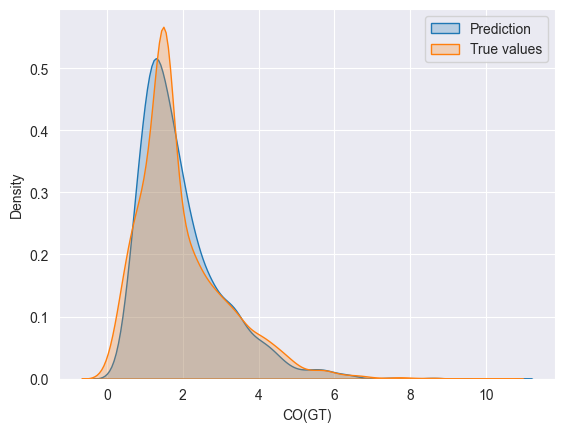

In [150]:
sns.kdeplot(x = l1_multiple_reg_test_prediction, fill=True, label="Prediction")
sns.kdeplot(x = y_test, fill=True, label="True values")
plt.legend()

In [151]:
input_into_the_tables("L1-Multiple regression",
                      l1_multiple_reg_train_prediction, y_train,
                      l1_multiple_reg_test_prediction, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

In [152]:
train_and_test_comparing.loc[["Linear regression", "Multiple regression", "L1-Multiple regression"]]

Train Data                         Test Data        \
                               R2   MSE  RMSE   MAE  MAPE        R2   MSE   
Linear regression           0.697 0.440 0.664 0.450 0.353     0.729 0.400   
Multiple regression         0.831 0.245 0.495 0.339 0.298     0.838 0.239   
L1-Multiple regression      0.831 0.245 0.495 0.339 0.298     0.838 0.239   

                                          
                        RMSE   MAE  MAPE  
Linear regression      0.632 0.430 0.330  
Multiple regression    0.489 0.328 0.280  
L1-Multiple regression 0.489 0.328 0.280

### Множественная линейная регрессия c L2 регуляризацией

In [153]:
ridge_model = Ridge()
param_grid = {'alpha':np.logspace(-10, 10)}

l2_multiple_search = GridSearchCV(
    estimator = ridge_model,
    param_grid = param_grid,
    scoring="neg_mean_squared_error"
)

l2_multiple_search.fit(X_train, y_train)
print(l2_multiple_search.best_params_)

{'alpha': np.float64(4.094915062380419)}


In [154]:
l2multiple_reg_train_prediction = l2_multiple_search.predict(X_train)
l2multiple_reg_test_prediction = l2_multiple_search.predict(X_test)

input_into_the_tables("L2-Multiple regression",
                      l2multiple_reg_train_prediction, y_train,
                      l2multiple_reg_test_prediction, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)
l2_multiple_search.best_estimator_.coef_

array([ 1.03160247e-03,  1.39727882e-01, -3.23752902e-03,  3.08751288e-03,
        4.55615296e-03,  1.31231790e-03, -1.83939288e-04, -1.51403976e-02,
       -4.38192261e-03, -2.57898293e-01, -2.22874482e-01,  5.26940359e-03,
        1.25818305e-03,  8.65387730e-03,  9.61910040e-03])

In [155]:
train_and_test_comparing.loc[["L1-Multiple regression", "L2-Multiple regression"]]

Train Data                         Test Data        \
                               R2   MSE  RMSE   MAE  MAPE        R2   MSE   
L1-Multiple regression      0.831 0.245 0.495 0.339 0.298     0.838 0.239   
L2-Multiple regression      0.831 0.245 0.495 0.339 0.297     0.838 0.239   

                                          
                        RMSE   MAE  MAPE  
L1-Multiple regression 0.489 0.328 0.280  
L2-Multiple regression 0.489 0.328 0.279

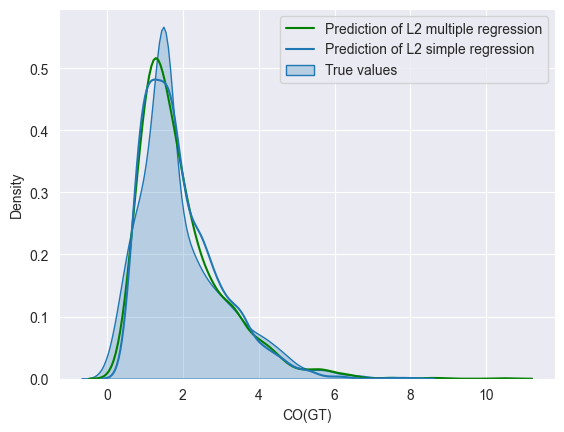

In [156]:
sns.kdeplot(x = l2multiple_reg_test_prediction, label="Prediction of L2 multiple regression", color="green")
sns.kdeplot(x = l2_regression_predict_on_test_y, label = "Prediction of L2 simple regression")
sns.kdeplot(x = y_test, fill=True, label="True values")
plt.legend()

Множественная модель регрессии с L2 регуляризацией лучше предсказывает малые и большие значения CO(GT), чем модель простой регрессии с L2 регуляризацией.

### Полиномиальная модель регрессии

In [157]:
p = PolynomialFeatures(2)
X_p = p.fit_transform(X_train)
X_p_test = p.fit_transform(X_test)
X_p

array([[1.000e+00, 9.320e+02, 7.100e+00, ..., 3.600e+01, 4.800e+01,
        6.400e+01],
       [1.000e+00, 8.730e+02, 2.500e+00, ..., 9.000e+00, 3.300e+01,
        1.210e+02],
       [1.000e+00, 1.403e+03, 1.510e+01, ..., 4.900e+01, 1.330e+02,
        3.610e+02],
       ...,
       [1.000e+00, 1.512e+03, 2.550e+01, ..., 1.000e+00, 1.500e+01,
        2.250e+02],
       [1.000e+00, 1.875e+03, 3.370e+01, ..., 1.600e+01, 7.600e+01,
        3.610e+02],
       [1.000e+00, 8.190e+02, 1.900e+00, ..., 4.900e+01, 9.800e+01,
        1.960e+02]], shape=(6656, 136))

Количество предикторов увеличилось

In [158]:
model = LinearRegression()
model.fit(X_p, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [159]:
model.coef_

array([-2.64435285e-04,  3.76147321e+00,  1.66887982e+02, -3.91776545e+00,
       -6.55043816e+00, -1.56366938e+00,  3.23064828e+00, -3.05500988e-01,
        2.27717097e+01,  3.86781382e+01, -1.99366345e+03,  2.18410270e-02,
       -1.61219584e+02, -6.37645931e+01,  2.10517613e+02,  5.12354109e+00,
       -2.32029347e-06, -3.67737623e-04,  1.31965332e-05,  1.45617945e-06,
       -5.17241033e-06, -1.17818416e-06,  2.14623061e-06, -5.34025584e-05,
       -1.28669140e-05,  1.22621679e-03, -1.87866015e-03, -1.43094392e-04,
        8.93085611e-05,  4.48201400e-05, -1.21450433e-05,  2.30713666e-02,
       -1.07069252e-03, -5.43085081e-04,  8.05960387e-04, -6.66007850e-05,
        1.28552407e-04,  1.38412204e-02,  7.83623319e-03, -2.44481936e-01,
       -8.28366291e-02, -1.59945431e-02, -3.16840919e-03,  1.73771892e-02,
        5.99661568e-03,  5.84944280e-06,  1.31098567e-05, -2.89672775e-05,
        1.65872126e-06, -3.02984608e-06, -2.81947340e-04, -1.50595802e-04,
        3.66557211e-03,  

In [160]:
polynomial_train_predict = model.predict(X_p)
polynomial_test_predict = model.predict(X_p_test)

input_into_the_tables("Polynomial regression",
                      polynomial_train_predict, y_train,
                      polynomial_test_predict, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

train_and_test_comparing

Train Data                          \
                                          R2   MSE  RMSE   MAE  MAPE   
Linear regression                      0.697 0.440 0.664 0.450 0.353   
Linear regression with L1              0.697 0.440 0.664 0.450 0.353   
Linear regression with L2              0.697 0.440 0.664 0.450 0.353   
Linear regression with ElasticNet      0.697 0.440 0.664 0.450 0.353   
Multiple regression                    0.831 0.245 0.495 0.339 0.298   
L1-Multiple regression                 0.831 0.245 0.495 0.339 0.298   
L2-Multiple regression                 0.831 0.245 0.495 0.339 0.297   
Polynomial regression                  0.880 0.174 0.418 0.288 0.258   

                                  Test Data                          
                                         R2   MSE  RMSE   MAE  MAPE  
Linear regression                     0.729 0.400 0.632 0.430 0.330  
Linear regression with L1             0.729 0.400 0.632 0.430 0.330  
Linear regression with L2             0.729 0.400 0.632 0.430 0.330  
Linear regression with ElasticNet     0.729 0.400 0.632 0.430 0.330  
Multiple regression                   0.838 0.239 0.489 0.328 0.280  
L1-Multiple regression                0.838 0.239 0.489 0.328 0.280  
L2-Multiple regression                0.838 0.239 0.489 0.328 0.279  
Polynomial regression                 0.871 0.189 0.435 0.290 0.252

На данный момент полиномиальная регрессия лучше всего отработала на данных - значения всех метрик, характеризующих ошибку, уменьшились, а коэффициент детерминации увеличился.

#### Полиномиальная модель регрессии с L1 регуляризацией

In [161]:
def lasso_objective(trial):
    alpha = trial.suggest_float('alpha', 1e-10, 1e10, log=True)
    model = Lasso(alpha=alpha)
    model.fit(X_simple_train, y_train)
    y_pred = model.predict(X_simple_test)
    mse = mean_squared_error(y_test, y_pred)
    return mse

study.optimize(lasso_objective, n_trials=100)
best_params = study.best_params
best_params

[I 2026-03-05 05:01:23,284] Trial 100 finished with value: 0.39967121112058174 and parameters: {'alpha': 1.1705429574134878e-09}. Best is trial 71 with value: 0.39967121111773063.
[I 2026-03-05 05:01:23,305] Trial 101 finished with value: 0.39967121111814957 and parameters: {'alpha': 2.5867961211752695e-10}. Best is trial 71 with value: 0.39967121111773063.
[I 2026-03-05 05:01:23,316] Trial 102 finished with value: 0.39967121111772874 and parameters: {'alpha': 1.0088170687363201e-10}. Best is trial 102 with value: 0.39967121111772874.
[I 2026-03-05 05:01:23,321] Trial 103 finished with value: 0.3996712111195868 and parameters: {'alpha': 7.975159664681463e-10}. Best is trial 102 with value: 0.39967121111772874.
[I 2026-03-05 05:01:23,328] Trial 104 finished with value: 0.3996712111177305 and parameters: {'alpha': 1.0153239975542111e-10}. Best is trial 102 with value: 0.39967121111772874.
[I 2026-03-05 05:01:23,342] Trial 105 finished with value: 0.39967121112523657 and parameters: {'alp

{'alpha': 1.002583269875971e-10}

In [163]:
lasso_polynomial_model = Lasso(alpha=best_params["alpha"])
lasso_polynomial_model.fit(X_p, y_train)
l1_polynomial_test_predict = lasso_polynomial_model.predict(X_p_test)
l1_polynomial_train_predict = lasso_polynomial_model.predict(X_p)

input_into_the_tables("Polynomial regression with Lasso reg",
                      l1_polynomial_train_predict, y_train,
                      l1_polynomial_test_predict, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

train_and_test_comparing

C:\Users\stwz13\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.152e+02, tolerance: 9.671e-01
  model = cd_fast.enet_coordinate_descent(


Train Data                          \
                                             R2   MSE  RMSE   MAE  MAPE   
Linear regression                         0.697 0.440 0.664 0.450 0.353   
Linear regression with L1                 0.697 0.440 0.664 0.450 0.353   
Linear regression with L2                 0.697 0.440 0.664 0.450 0.353   
Linear regression with ElasticNet         0.697 0.440 0.664 0.450 0.353   
Multiple regression                       0.831 0.245 0.495 0.339 0.298   
L1-Multiple regression                    0.831 0.245 0.495 0.339 0.298   
L2-Multiple regression                    0.831 0.245 0.495 0.339 0.297   
Polynomial regression                     0.880 0.174 0.418 0.288 0.258   
Polynomial regression with Lasso reg      0.873 0.185 0.430 0.297 0.266   

                                     Test Data                          
                                            R2   MSE  RMSE   MAE  MAPE  
Linear regression                        0.729 0.400 0.632 0.430 0.330  
Linear regression with L1                0.729 0.400 0.632 0.430 0.330  
Linear regression with L2                0.729 0.400 0.632 0.430 0.330  
Linear regression with ElasticNet        0.729 0.400 0.632 0.430 0.330  
Multiple regression                      0.838 0.239 0.489 0.328 0.280  
L1-Multiple regression                   0.838 0.239 0.489 0.328 0.280  
L2-Multiple regression                   0.838 0.239 0.489 0.328 0.279  
Polynomial regression                    0.871 0.189 0.435 0.290 0.252  
Polynomial regression with Lasso reg     0.874 0.186 0.431 0.290 0.254

В целом метрики для модели полиномиальной регрессии с применением Lasso регуляризации не изменились в сравнении с полиномиальной регрессией без регулярзации.

### Байесовская регрессия

In [166]:
bayesian_model = BayesianRidge()
bayesian_model.fit(X_train, y_train)
bayesian_train_predict = bayesian_model.predict(X_train)
bayesian_test_predict = bayesian_model.predict(X_test)

input_into_the_tables("Bayesian regression",
                      bayesian_train_predict, y_train,
                      bayesian_test_predict, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)


train_and_test_comparing

Train Data                          \
                                             R2   MSE  RMSE   MAE  MAPE   
Linear regression                         0.697 0.440 0.664 0.450 0.353   
Linear regression with L1                 0.697 0.440 0.664 0.450 0.353   
Linear regression with L2                 0.697 0.440 0.664 0.450 0.353   
Linear regression with ElasticNet         0.697 0.440 0.664 0.450 0.353   
Multiple regression                       0.831 0.245 0.495 0.339 0.298   
L1-Multiple regression                    0.831 0.245 0.495 0.339 0.298   
L2-Multiple regression                    0.831 0.245 0.495 0.339 0.297   
Polynomial regression                     0.880 0.174 0.418 0.288 0.258   
Polynomial regression with Lasso reg      0.873 0.185 0.430 0.297 0.266   
Bayesian regression                       0.831 0.245 0.495 0.339 0.297   

                                     Test Data                          
                                            R2   MSE  RMSE   MAE  MAPE  
Linear regression                        0.729 0.400 0.632 0.430 0.330  
Linear regression with L1                0.729 0.400 0.632 0.430 0.330  
Linear regression with L2                0.729 0.400 0.632 0.430 0.330  
Linear regression with ElasticNet        0.729 0.400 0.632 0.430 0.330  
Multiple regression                      0.838 0.239 0.489 0.328 0.280  
L1-Multiple regression                   0.838 0.239 0.489 0.328 0.280  
L2-Multiple regression                   0.838 0.239 0.489 0.328 0.279  
Polynomial regression                    0.871 0.189 0.435 0.290 0.252  
Polynomial regression with Lasso reg     0.874 0.186 0.431 0.290 0.254  
Bayesian regression                      0.838 0.239 0.489 0.328 0.279

Байесовская модель регрессии отработала хуже, чем модель полиномиальной регрессии.

### Робастная регрессия

In [171]:
huber_model = HuberRegressor(max_iter=10000)
huber_model.fit(X_train, y_train)
huber_train_predict = huber_model.predict(X_train)
huber_test_predict = huber_model.predict(X_test)

input_into_the_tables("Huber regression",
                      huber_train_predict, y_train,
                      huber_test_predict, y_test,
                      sklearn_and_custom_comparing,
                      train_and_test_comparing)

train_and_test_comparing

Train Data                          \
                                             R2   MSE  RMSE   MAE  MAPE   
Linear regression                         0.697 0.440 0.664 0.450 0.353   
Linear regression with L1                 0.697 0.440 0.664 0.450 0.353   
Linear regression with L2                 0.697 0.440 0.664 0.450 0.353   
Linear regression with ElasticNet         0.697 0.440 0.664 0.450 0.353   
Multiple regression                       0.831 0.245 0.495 0.339 0.298   
L1-Multiple regression                    0.831 0.245 0.495 0.339 0.298   
L2-Multiple regression                    0.831 0.245 0.495 0.339 0.297   
Polynomial regression                     0.880 0.174 0.418 0.288 0.258   
Polynomial regression with Lasso reg      0.873 0.185 0.430 0.297 0.266   
Bayesian regression                       0.831 0.245 0.495 0.339 0.297   
Huber regression                          0.825 0.254 0.504 0.335 0.289   

                                     Test Data                          
                                            R2   MSE  RMSE   MAE  MAPE  
Linear regression                        0.729 0.400 0.632 0.430 0.330  
Linear regression with L1                0.729 0.400 0.632 0.430 0.330  
Linear regression with L2                0.729 0.400 0.632 0.430 0.330  
Linear regression with ElasticNet        0.729 0.400 0.632 0.430 0.330  
Multiple regression                      0.838 0.239 0.489 0.328 0.280  
L1-Multiple regression                   0.838 0.239 0.489 0.328 0.280  
L2-Multiple regression                   0.838 0.239 0.489 0.328 0.279  
Polynomial regression                    0.871 0.189 0.435 0.290 0.252  
Polynomial regression with Lasso reg     0.874 0.186 0.431 0.290 0.254  
Bayesian regression                      0.838 0.239 0.489 0.328 0.279  
Huber regression                         0.834 0.244 0.494 0.321 0.271